TASK 1: DATASET DIMENSIONS
Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)
Testing Images Shape  : (10000, 32, 32, 3)
Testing Labels Shape   : (10000, 1)


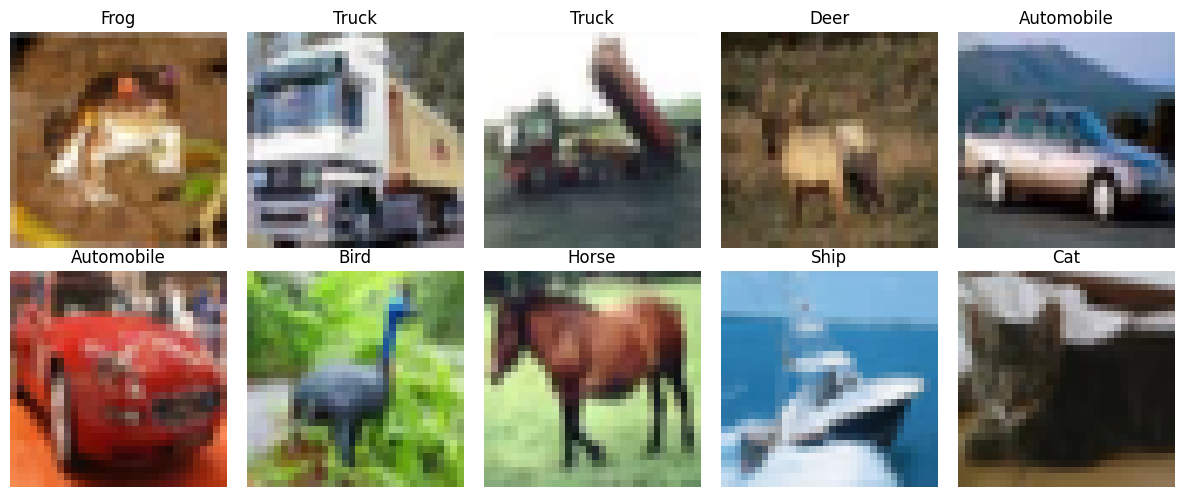

BENCHMARKING CNN ARCHITECTURES: 
Completed LeNet-5    | Params: 121,182| Acc: 58.79% | Time: 19.91s
Completed AlexNet    | Params: 4,026,954| Acc: 67.68% | Time: 56.86s
Completed VGG16      | Params: 14,781,642| Acc: 77.61% | Time: 195.61s
Completed GoogleNet  | Params: 22,066,346| Acc: 69.91% | Time: 85.54s
Completed ResNet50   | Params: 23,851,274| Acc: 78.41% | Time: 109.62s
TRAINING RESNET50 (FEATURE EXTRACTION - 10 EPOCHS)
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 38ms/step - accuracy: 0.7028 - loss: 0.8616 - val_accuracy: 0.7596 - val_loss: 0.6919
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7657 - loss: 0.6692 - val_accuracy: 0.7759 - val_loss: 0.6341
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7885 - loss: 0.6053 - val_accuracy: 0.7805 - val_loss: 0.6230
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8058 - loss: 0.5529 - val_accuracy: 0.7820 - val_loss: 0.6480
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━

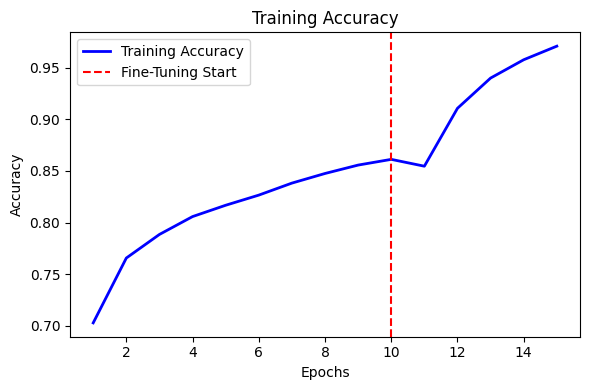

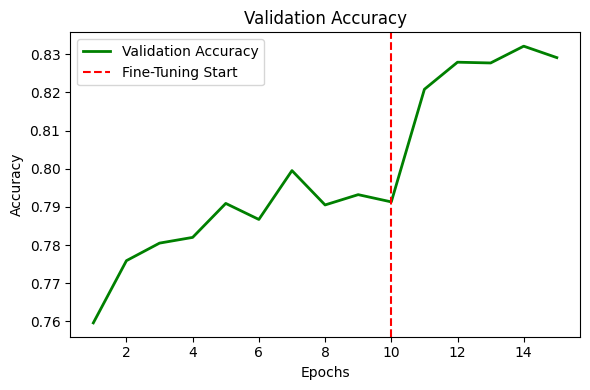

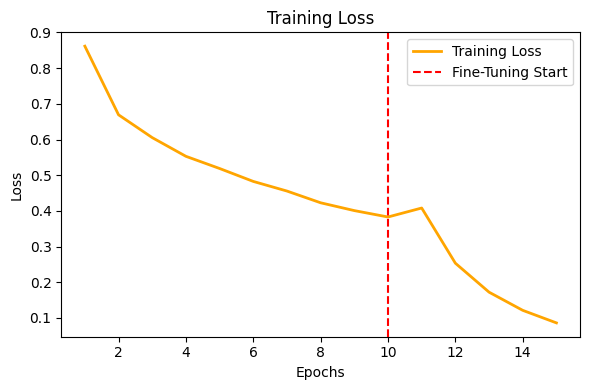

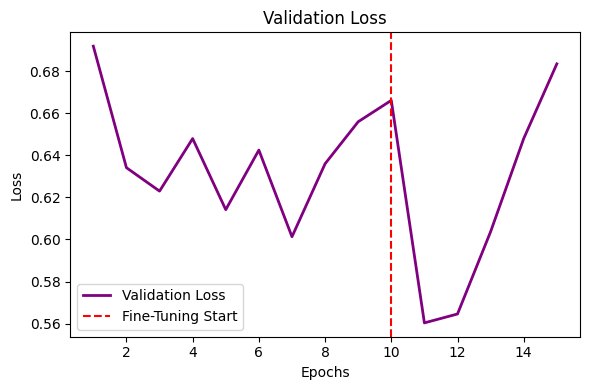

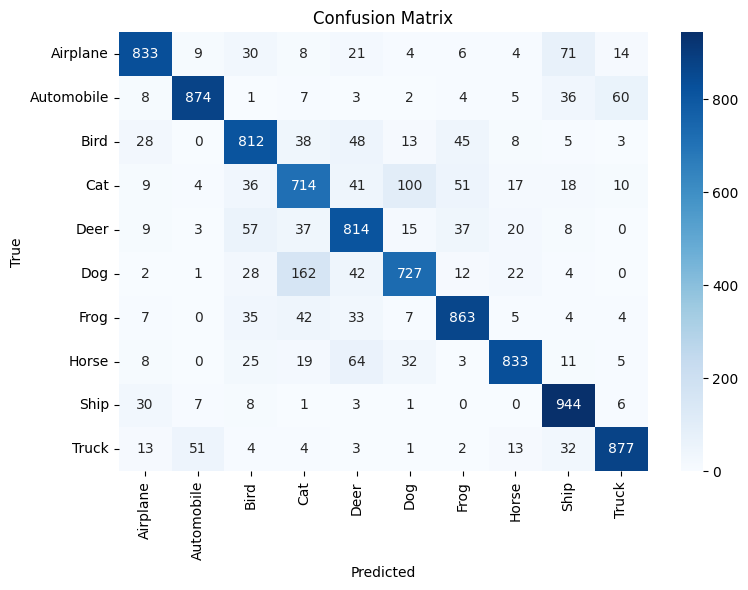

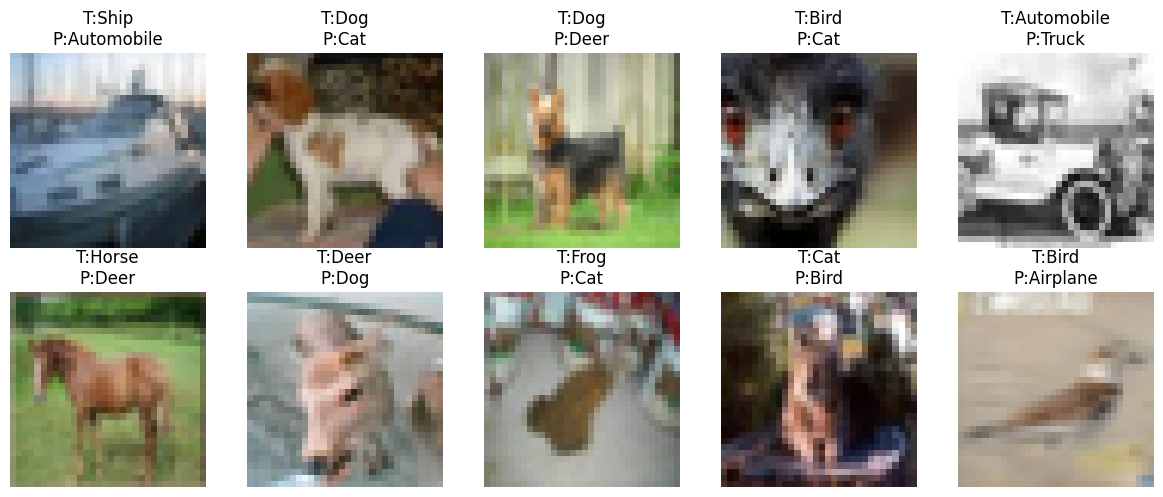

COMPARISON OF CNN ARCHITECTURES: 
Model        | Parameters   | Accuracy (%) | Training Time (s) 
LeNet-5      | 121,182      | 58.79        | 19.91             
AlexNet      | 4,026,954    | 67.68        | 56.86             
VGG16        | 14,781,642   | 77.61        | 195.61            
GoogleNet    | 22,066,346   | 69.91        | 85.54             
ResNet50     | 23,851,274   | 78.41        | 109.62            
HYPERPARAMETER STUDY RESULTS: 
Opt    | LR      | Batch  | Dense  | Frozen   | Accuracy (%) | Time (s)
Adam   | 0.001   | 32     | 128    | All      | 77.91        | 75.70   
Adam   | 0.0001  | 32     | 128    | Partial  | 82.86        | 95.71   
Adam   | 0.001   | 16     | 128    | All      | 78.20        | 94.14   
Adam   | 0.001   | 64     | 256    | All      | 78.19        | 65.31   
SGD    | 0.001   | 32     | 128    | All      | 72.77        | 84.71   
FINE-TUNING IMPACT COMPARISON RESNET50: 
Metric               | Before FT            | After FT             | Improveme

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# DATASET PREPARATION
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Normalize pixel values [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("="*60)
print("TASK 1: DATASET DIMENSIONS")
print("="*60)
print(f"Training Images Shape : {x_train.shape}")
print(f"Training Labels Shape : {y_train.shape}")
print(f"Testing Images Shape  : {x_test.shape}")
print(f"Testing Labels Shape   : {y_test.shape}")

BATCH_SIZE = 32

# Plot 1: Sample CIFAR-10 Images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.savefig('cifar10_samples.eps', format='eps', bbox_inches='tight')
plt.show()

# MODEL ARCHITECTURE BUILDERS
def build_lenet5():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.AveragePooling2D((2, 2)),
        layers.Conv2D(32, (5, 5), activation='relu'),
        layers.AveragePooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

def build_alexnet():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(192, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

def build_transfer_model(app_fn, prep_fn, scale_factor=3):
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.UpSampling2D((scale_factor, scale_factor))(inputs)
    x = layers.Lambda(prep_fn)(x)
    base = app_fn(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    y = layers.GlobalAveragePooling2D()(base.output)
    y = layers.Dense(128, activation='relu')(y)
    y = layers.Dropout(0.2)(y)
    outputs = layers.Dense(10, activation='softmax')(y)

    model = models.Model(inputs, outputs)
    return model, base

# COMPARATIVE STUDY OF CNN ARCHITECTURES
print("BENCHMARKING CNN ARCHITECTURES: ")

arch_models = {
    'LeNet-5': (build_lenet5(), x_train_norm, x_test_norm),
    'AlexNet': (build_alexnet(), x_train_norm, x_test_norm),
    'VGG16': (build_transfer_model(tf.keras.applications.VGG16, tf.keras.applications.vgg16.preprocess_input)[0], x_train, x_test),
    'GoogleNet': (build_transfer_model(tf.keras.applications.InceptionV3, tf.keras.applications.inception_v3.preprocess_input)[0], x_train, x_test),
    'ResNet50': (build_transfer_model(tf.keras.applications.ResNet50, tf.keras.applications.resnet50.preprocess_input)[0], x_train, x_test)
}

arch_results = {}

for name, (model, tr_x, te_x) in arch_models.items():
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    # 3 benchmark epochs on full dataset
    model.fit(tr_x, y_train_cat, epochs=3, batch_size=BATCH_SIZE, verbose=0)
    elapsed = time.time() - t0
    _, acc = model.evaluate(te_x, y_test_cat, verbose=0, batch_size=BATCH_SIZE)
    arch_results[name] = {'Parameters': model.count_params(), 'Accuracy': acc * 100, 'Time': elapsed}
    print(f"Completed {name:<10} | Params: {model.count_params():,}| Acc: {acc*100:.2f}% | Time: {elapsed:.2f}s")

# MAIN MODEL TRAINING ResNet50 - Feature Extraction / Frozen Base
resnet_model, resnet_base = build_transfer_model(tf.keras.applications.ResNet50, tf.keras.applications.resnet50.preprocess_input)
resnet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("TRAINING RESNET50 (FEATURE EXTRACTION - 10 EPOCHS)")
start_train_time = time.time()
h1 = resnet_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

# Benchmark metrics BEFORE Fine-Tuning
val_loss_before, val_acc_before = resnet_model.evaluate(x_test, y_test_cat, verbose=0, batch_size=BATCH_SIZE)
y_pred_b = np.argmax(resnet_model.predict(x_test, batch_size=BATCH_SIZE, verbose=0), axis=1)
y_true = y_test.flatten()
p_b, r_b, f1_b, _ = precision_recall_fscore_support(y_true, y_pred_b, average='weighted', zero_division=0)

# HYPERPARAMETER STUDY
print("HYPERPARAMETER EXPERIMENTAL STUDY: ")

hp_configs = [
    {"lr": 0.001,  "batch_size": 32, "opt": "Adam", "dense": 128, "frozen": "All"},
    {"lr": 0.0001, "batch_size": 32, "opt": "Adam", "dense": 128, "frozen": "Partial"},
    {"lr": 0.001,  "batch_size": 16, "opt": "Adam", "dense": 128, "frozen": "All"},
    {"lr": 0.001,  "batch_size": 64, "opt": "Adam", "dense": 256, "frozen": "All"},
    {"lr": 0.001,  "batch_size": 32, "opt": "SGD",  "dense": 128, "frozen": "All"},
]

hp_results = []
for config in hp_configs:
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.UpSampling2D((3, 3))(inputs)
    x = layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(x)
    base = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_tensor=x)

    if config["frozen"] == "All":
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:-15]:
            layer.trainable = False

    y = layers.GlobalAveragePooling2D()(base.output)
    y = layers.Dense(config["dense"], activation='relu')(y)
    outputs = layers.Dense(10, activation='softmax')(y)

    hp_model = models.Model(inputs, outputs)
    opt = optimizers.Adam(learning_rate=config["lr"]) if config["opt"] == "Adam" else optimizers.SGD(learning_rate=config["lr"])
    hp_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    hp_model.fit(x_train, y_train_cat, epochs=2, batch_size=config["batch_size"], verbose=0)
    elapsed = time.time() - t0
    _, test_acc = hp_model.evaluate(x_test, y_test_cat, verbose=0, batch_size=config["batch_size"])
    hp_results.append({**config, "acc": test_acc * 100, "time": elapsed})

# --- TASK 4: FINE-TUNING (UNFROZEN TOP CONVOLUTIONAL BLOCK) ---
print("FINE-TUNING RESNET50 (5 EPOCHS)")
resnet_base.trainable = True
for layer in resnet_base.layers[:-15]:
    layer.trainable = False

resnet_model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
h2 = resnet_model.fit(
    x_train, y_train_cat,
    epochs=5,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
total_training_time = time.time() - start_train_time

# Benchmark metrics AFTER Fine-Tuning
val_loss_after, val_acc_after = resnet_model.evaluate(x_test, y_test_cat, verbose=0, batch_size=BATCH_SIZE)
y_pred_a = np.argmax(resnet_model.predict(x_test, batch_size=BATCH_SIZE, verbose=0), axis=1)
p_a, r_a, f1_a, _ = precision_recall_fscore_support(y_true, y_pred_a, average='weighted', zero_division=0)

# MANDATORY PLOTS GENERATION
tr_acc = h1.history['accuracy'] + h2.history['accuracy']
val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
tr_loss = h1.history['loss'] + h2.history['loss']
val_loss = h1.history['val_loss'] + h2.history['val_loss']
epochs_range = range(1, len(tr_acc) + 1)

def plot_and_save(data, title, ylabel, color, fname):
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, data, label=title, color=color, linewidth=2)
    plt.axvline(x=10, color='red', linestyle='--', label='Fine-Tuning Start')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname, format='eps', bbox_inches='tight')
    plt.show()

plot_and_save(tr_acc, 'Training Accuracy', 'Accuracy', 'blue', 'training_accuracy.eps')
plot_and_save(val_acc, 'Validation Accuracy', 'Accuracy', 'green', 'validation_accuracy.eps')
plot_and_save(tr_loss, 'Training Loss', 'Loss', 'orange', 'training_loss.eps')
plot_and_save(val_loss, 'Validation Loss', 'Loss', 'purple', 'validation_loss.eps')

# Plot 6: Confusion Matrix
cm = confusion_matrix(y_true, y_pred_a)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.eps', format='eps', bbox_inches='tight')
plt.show()

# Plot 7: Misclassified Images
mis_idx = np.where(y_pred_a != y_true)[0]
plt.figure(figsize=(12, 5))
for i, idx in enumerate(mis_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred_a[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('misclassified_images.eps', format='eps', bbox_inches='tight')
plt.show()

print("COMPARISON OF CNN ARCHITECTURES: ")
print(f"{'Model':<12} | {'Parameters':<12} | {'Accuracy (%)':<12} | {'Training Time (s)':<18}")
for name, data in arch_results.items():
    print(f"{name:<12} | {data['Parameters']:<12,} | {data['Accuracy']:<12.2f} | {data['Time']:<18.2f}")

print("HYPERPARAMETER STUDY RESULTS: ")
print(f"{'Opt':<6} | {'LR':<7} | {'Batch':<6} | {'Dense':<6} | {'Frozen':<8} | {'Accuracy (%)':<12} | {'Time (s)':<8}")
for r in hp_results:
    print(f"{r['opt']:<6} | {r['lr']:<7} | {r['batch_size']:<6} | {r['dense']:<6} | {r['frozen']:<8} | {r['acc']:<12.2f} | {r['time']:<8.2f}")

print("FINE-TUNING IMPACT COMPARISON RESNET50: ")
print(f"{'Metric':<20} | {'Before FT':<20} | {'After FT':<20} | {'Improvement':<10}")
print(f"{'Test Accuracy':<20} | {val_acc_before * 100:<19.2f}% | {val_acc_after * 100:<19.2f}% | {+(val_acc_after - val_acc_before)*100:<+8.2f}%")
print(f"{'Precision':<20} | {p_b:<20.4f} | {p_a:<20.4f} | {+(p_a - p_b):<+8.4f}")
print(f"{'Recall':<20} | {r_b:<20.4f} | {r_a:<20.4f} | {+(r_a - r_b):<+8.4f}")
print(f"{'F1-Score':<20} | {f1_b:<20.4f} | {f1_a:<20.4f} | {+(f1_a - f1_b):<+8.4f}")

print("FINAL PERFORMANCE METRICS - RESNET50: ")
print(f"Training Accuracy           : {tr_acc[-1] * 100:.2f}%")
print(f"Testing Accuracy            : {val_acc_after * 100:.2f}%")
print(f"Precision                   : {p_a:.4f}")
print(f"Recall                      : {r_a:.4f}")
print(f"F1-score                    : {f1_a:.4f}")
print(f"Training Time               : {total_training_time:.2f} seconds")
print(f"Total Parameters            : {resnet_model.count_params():,}")

print("\nDetailed Classification Report:\n")
print(classification_report(y_true, y_pred_a, target_names=class_names, zero_division=0))